13:15:44 - cmdstanpy - INFO - Chain [1] start processing
13:15:52 - cmdstanpy - INFO - Chain [1] done processing



ARIMA
------------------------------
MAE : 0.9162
RMSE: 1.0405

Prophet
------------------------------
MAE : 0.4946
RMSE: 0.6454

XGBoost
------------------------------
MAE : 0.3316
RMSE: 0.4784


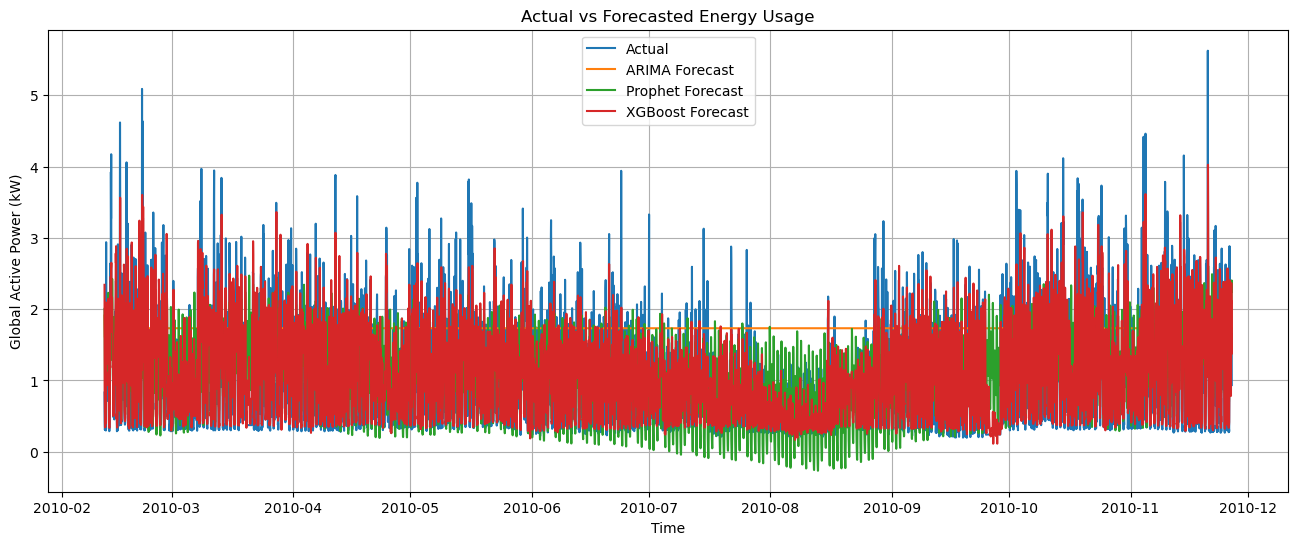

In [1]:
# ============================================================
# Task 3: Energy Consumption Time Series Forecasting
# Dataset: Household Power Consumption Dataset
# ============================================================

# Install Prophet if not installed:
# pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# ============================================================
# 1. Load Dataset
# ============================================================

df = pd.read_csv(
    r"G:\household_power_consumption.txt\household_power_consumption.txt",
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values='?',
    low_memory=False
)

# ============================================================
# 2. Data Preprocessing
# ============================================================

df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df.dropna(subset=['Global_active_power'], inplace=True)

df.set_index('Datetime', inplace=True)

# Resample to hourly average
hourly = df['Global_active_power'].resample('H').mean()

hourly = hourly.fillna(method='ffill')

# ============================================================
# 3. Feature Engineering
# ============================================================

data = hourly.to_frame(name='power')

data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)

# Lag Features
data['lag_1'] = data['power'].shift(1)
data['lag_24'] = data['power'].shift(24)

data.dropna(inplace=True)

# ============================================================
# 4. Train-Test Split
# ============================================================

train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

y_train = train['power']
y_test = test['power']

# ============================================================
# 5. ARIMA Model
# ============================================================

arima_model = ARIMA(y_train, order=(5,1,0))

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

# ============================================================
# 6. Prophet Model
# ============================================================

prophet_train = train.reset_index()[['Datetime','power']]
prophet_train.columns = ['ds','y']

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='H'
)

forecast = prophet_model.predict(future)

prophet_forecast = forecast['yhat'].tail(len(test)).values

# ============================================================
# 7. XGBoost Model
# ============================================================

features = [
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'lag_1',
    'lag_24'
]

X_train = train[features]
X_test = test[features]

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

# ============================================================
# 8. Evaluation
# ============================================================

def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"\n{model_name}")
    print("-"*30)
    print("MAE :", round(mae,4))
    print("RMSE:", round(rmse,4))

evaluate(y_test, arima_forecast, "ARIMA")
evaluate(y_test, prophet_forecast, "Prophet")
evaluate(y_test, xgb_forecast, "XGBoost")

# ============================================================
# 9. Actual vs Forecast Visualization
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    arima_forecast,
    label='ARIMA Forecast'
)

plt.plot(
    y_test.index,
    prophet_forecast,
    label='Prophet Forecast'
)

plt.plot(
    y_test.index,
    xgb_forecast,
    label='XGBoost Forecast'
)

plt.title('Actual vs Forecasted Energy Usage')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)

plt.show()